In [ ]:
%pip install puremacro


# Where does wealth inequality come from?

Idiosyncratic income risk plus a borrowing constraint makes households save
for precautionary reasons, producing a non-degenerate wealth distribution even
when everyone is *ex-ante* identical. We solve the **Aiyagari (1994)** general
equilibrium, contrast it with the **Huggett (1993)** bond economy, and show
that adding *ex-ante* heterogeneity in patience (β) fattens the top tail — the
canonical reason quantitative models need permanent heterogeneity to match the
data. All with `puremacro.vfi`.

## The model in three equations

**Households.** A continuum of households face idiosyncratic labor-productivity risk $z$
(an AR(1), discretized by Tauchen) and cannot borrow. They solve
$$ V(a,z) = \max_{a'\ge 0}\; u(c) + \beta\,\mathbb{E}\!\left[V(a',z')\mid z\right]
\quad\text{s.t.}\quad c = w\,e^{z} + (1+r)\,a - a', $$
with $u(c)=\log c$ here ($\gamma=1$). The constraint $a'\ge 0$ is the engine of the model.

**Firms.** A representative Cobb-Douglas firm sets factor prices from aggregates:
$$ r = \alpha\,(K/L)^{\alpha-1} - \delta, \qquad w = (1-\alpha)\,(K/L)^{\alpha}. $$

**Equilibrium.** Let $\mu$ be the stationary distribution induced by the saving policy.
The interest rate clears the capital market, $K = \int a\, d\mu(a,z)$. In **Huggett** the
asset is a bond in zero net supply, so clearing is $\int a\,d\mu = 0$ and the equilibrium
rate sits strictly below $1/\beta-1$.

**Intuition.** With no borrowing and uninsurable income risk, households self-insure by
holding a precautionary buffer of assets. That buffer is why a non-degenerate wealth
distribution emerges even though everyone is *ex-ante* identical — and why the clearing
rate is pushed below the complete-markets benchmark $1/\beta-1$: the extra desire to save
bids the return down. Permanent differences in patience $\beta$ then stretch the
distribution further — patient households climb the asset grid, impatient ones pile near
the constraint.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.vfi import (
    aiyagari_steady_state, huggett_steady_state, lorenz_and_gini,
    VFIProblem, solve_permanent_types,
)

## 1. Aiyagari: incomplete markets in general equilibrium
Households face AR(1) labor-productivity risk and cannot borrow (`a ≥ 0`); the
interest rate adjusts so household saving equals the capital firms demand.

In [2]:
ai = aiyagari_steady_state(n_z=5, n_a=120, a_max=60.0, gamma=1.0)
eq = ai["equilibrium"]
a_grid = np.asarray(eq.problem.a_grid, dtype=float)
z_grid = np.asarray(eq.problem.z_grid, dtype=float)
P_z = np.asarray(eq.problem.P_z, dtype=float)
mu_ai = eq.distribution                                  # (n_a, n_z)
gini_ai = ai["wealth_gini"]
print(f"Aiyagari:  r* = {ai['r']:.4f},  K = {ai['K']:.2f},  wealth Gini = {gini_ai:.3f}")
assert 0.40 < gini_ai < 0.80, gini_ai   # docstring: n_z=5 gives a stable Gini ~0.6

Aiyagari:  r* = 0.0306,  K = 7.48,  wealth Gini = 0.632


**Read the output.** The complete-markets benchmark is $1/\beta-1 = 1/0.96-1 \approx 0.042$.
The equilibrium $r^*$ printed above sits *below* it: that gap is the precautionary wedge —
households' self-insurance demand for assets bids the return down. The wealth Gini near
$0.6$ is produced entirely by idiosyncratic risk plus the borrowing constraint, with no
ex-ante heterogeneity yet.

## 2. Permanent β-heterogeneity fattens the tail
Hold the Aiyagari prices fixed and split the population into a *patient* and an
*impatient* type. The patient over-accumulate; the impatient cluster near the
constraint. The population mixture is more dispersed than the homogeneous economy.

In [3]:
alpha, delta = 0.36, 0.08
def wage_of_r(r):
    KL = (alpha / (r + delta)) ** (1.0 / (1.0 - alpha))
    return (1.0 - alpha) * KL ** alpha

r_star, w_star = ai["r"], wage_of_r(ai["r"])
betas, weights = [0.96, 0.93], [0.5, 0.5]

def build_type(t):
    b = betas[t]
    def rf(ap, a, z, xp=np):
        c = w_star * xp.exp(z) + (1.0 + r_star) * a - ap
        return xp.where(c > 0.0, xp.log(xp.maximum(c, 1e-12)), -np.inf)
    return VFIProblem(a_grid=a_grid, z_grid=z_grid, P_z=P_z, return_fn=rf,
                      beta=b, options=dict(tol=1e-9, n_howard=40))

pt = solve_permanent_types(build_type, weights)
mu_mix = pt.mixture_distribution()
wealth_mix = np.broadcast_to(a_grid[:, None], mu_mix.shape)
_, _, gini_mix = lorenz_and_gini(mu_mix, wealth_mix)
print(f"β-heterogeneous mixture wealth Gini = {gini_mix:.3f}  (vs {gini_ai:.3f})")
assert gini_mix > gini_ai, (gini_mix, gini_ai)   # if marginal, widen the β spread (e.g. 0.92)

β-heterogeneous mixture wealth Gini = 0.794  (vs 0.632)


## 3. Huggett: a bond economy in zero net supply
A pure-exchange economy where the single asset is a bond that nets to zero.
The clearing rate sits below `1/β − 1`; some agents borrow.

In [4]:
hu = huggett_steady_state(n_z=7, n_a=150)
a_grid_hu = np.asarray(hu["equilibrium"].problem.a_grid, dtype=float)
mu_hu = hu["equilibrium"].distribution
print(f"Huggett:   r = {hu['r']:.4f},  mean assets = {hu['mean_assets']:.2e}, "
      f"borrowing share = {hu['frac_borrowing']:.2f}")
assert abs(hu["equilibrium"].residual) < 1e-2
assert 0.0 < hu["frac_borrowing"] < 1.0

Huggett:   r = 0.0046,  mean assets = 7.18e-04, borrowing share = 0.68


### Hero figure — Lorenz curves
The β-heterogeneous mixture lies further from the 45° line of perfect equality.

/private/var/containers/Bundle/Application/DC3E5846-3887-4ADC-A213-9BA44E8D6751/Juno.app/python-home/lib/python3.13/_juno_bridges.py:140: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Noto Sans.
  return _orig_get_layout(self, renderer)
/private/var/containers/Bundle/Application/DC3E5846-3887-4ADC-A213-9BA44E8D6751/Juno.app/pinned-packages/IPython/core/pylabtools.py:134: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Noto Sans.
  fig.canvas.print_figure(bytes_io, **kw)


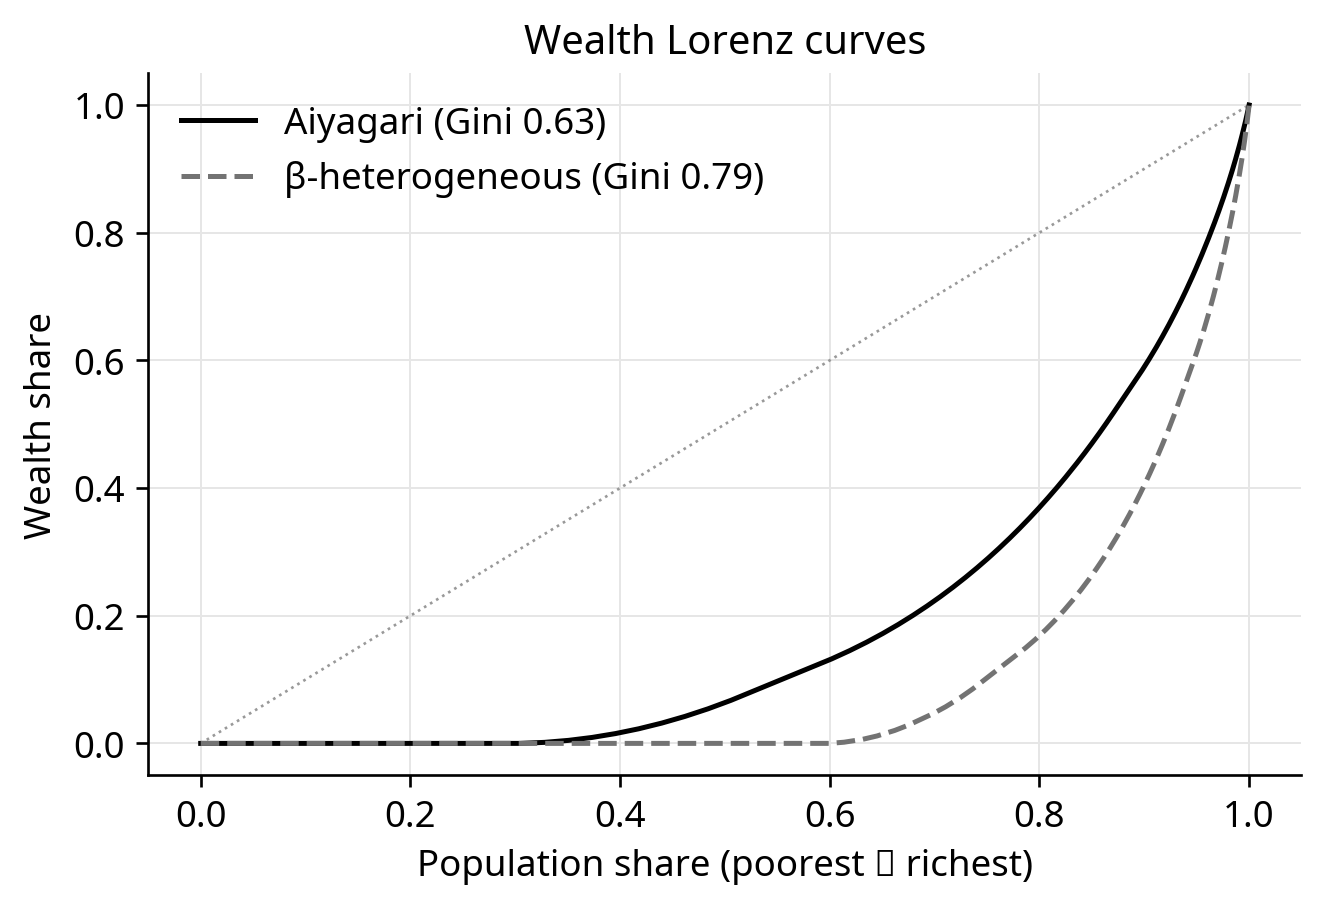

In [5]:
cols = _nbstyle.palette(2)
pop_ai, val_ai, _ = lorenz_and_gini(mu_ai, np.broadcast_to(a_grid[:, None], mu_ai.shape))
pop_mx, val_mx, _ = lorenz_and_gini(mu_mix, wealth_mix)
fig, ax = plt.subplots()
ax.plot([0, 1], [0, 1], color="0.6", linewidth=0.8, linestyle=":")
ax.plot(pop_ai, val_ai, color=cols[0], label=f"Aiyagari (Gini {gini_ai:.2f})")
ax.plot(pop_mx, val_mx, color=cols[1], linestyle="--",
        label=f"β-heterogeneous (Gini {gini_mix:.2f})")
ax.set_xlabel("Population share (poorest → richest)")
ax.set_ylabel("Wealth share")
ax.set_title("Wealth Lorenz curves")
ax.legend(loc="upper left")
plt.show()

### Supporting — wealth density by income state, and the Huggett asset distribution

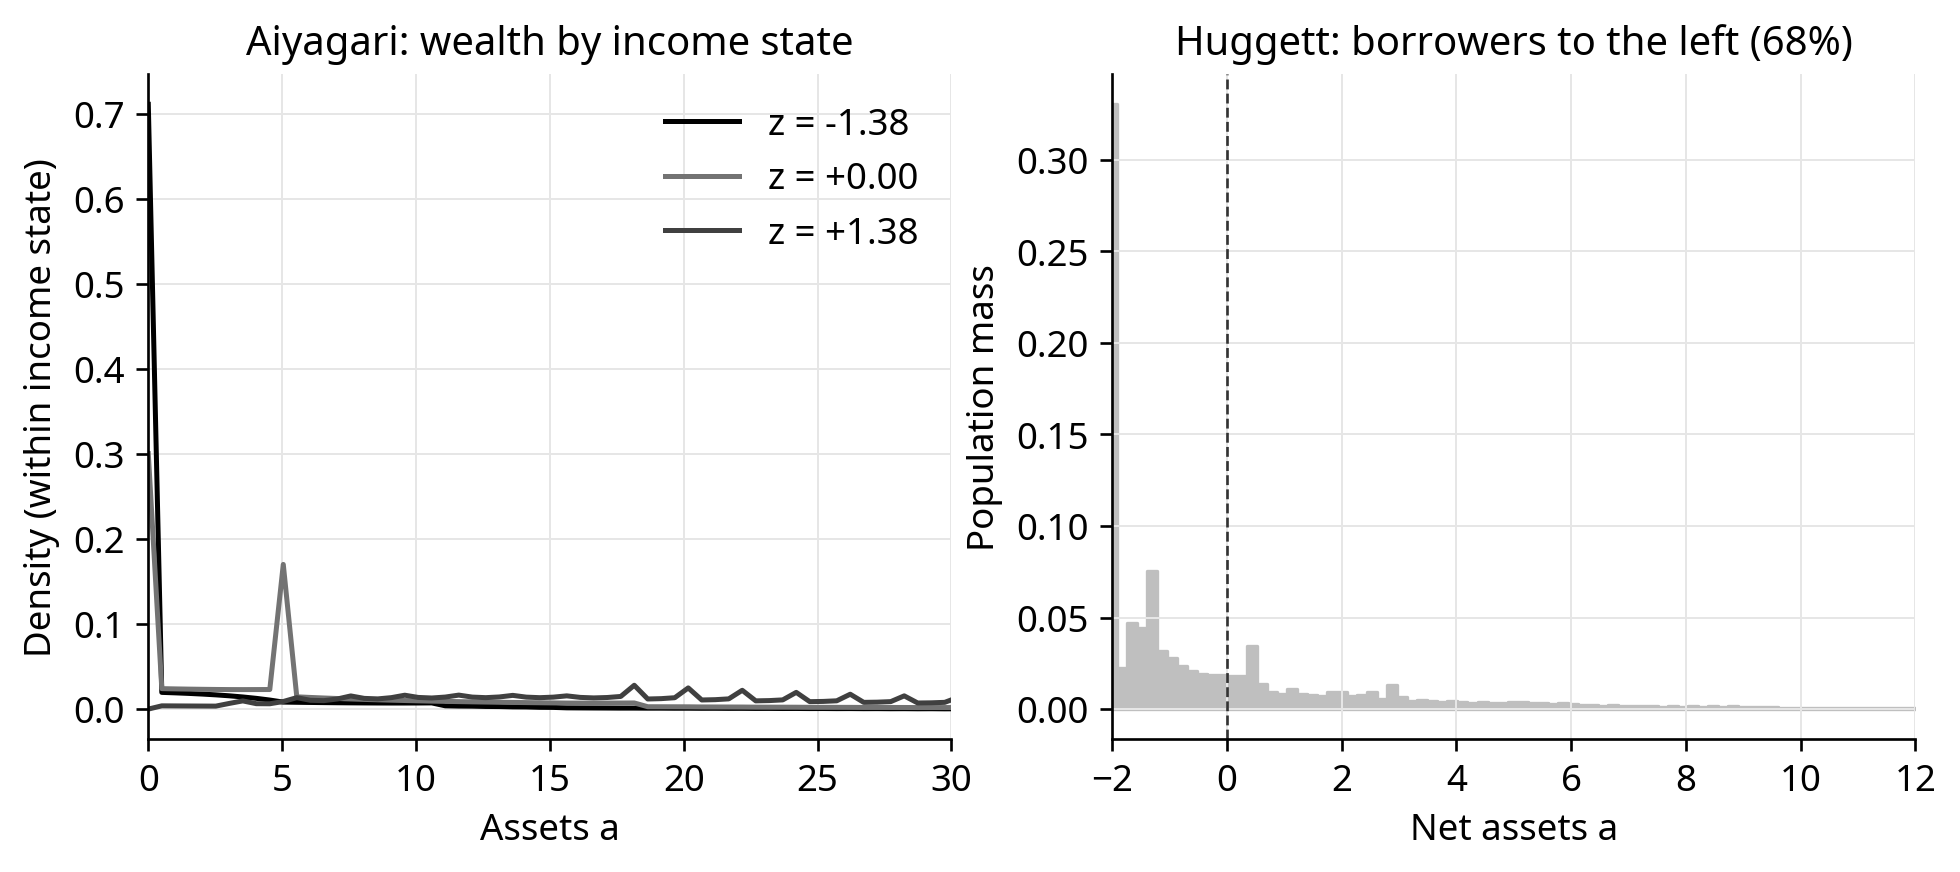

In [6]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.5, 3.6))
dens_ai = mu_ai / mu_ai.sum(axis=0, keepdims=True)       # column-normalize per z
for j, c in zip([0, len(z_grid) // 2, len(z_grid) - 1], _nbstyle.palette(3)):
    axL.plot(a_grid, dens_ai[:, j], color=c, label=f"z = {z_grid[j]:+.2f}")
axL.set_xlim(0, 30)
axL.set_xlabel("Assets a"); axL.set_ylabel("Density (within income state)")
axL.set_title("Aiyagari: wealth by income state"); axL.legend()

mu_hu_a = mu_hu.sum(axis=1)                               # marginal over z
axR.fill_between(a_grid_hu, mu_hu_a, color="0.75", step="mid")
axR.axvline(0.0, color="0.2", linewidth=0.8, linestyle="--")
axR.set_xlim(a_grid_hu[0], 12)
axR.set_xlabel("Net assets a"); axR.set_ylabel("Population mass")
axR.set_title(f"Huggett: borrowers to the left ({hu['frac_borrowing']:.0%})")
plt.show()

### Supporting — the consumption-saving policy
Below a threshold the borrowing constraint binds and `a' = 0` (the flat segment
on the 45° line); above it households save out of higher income.

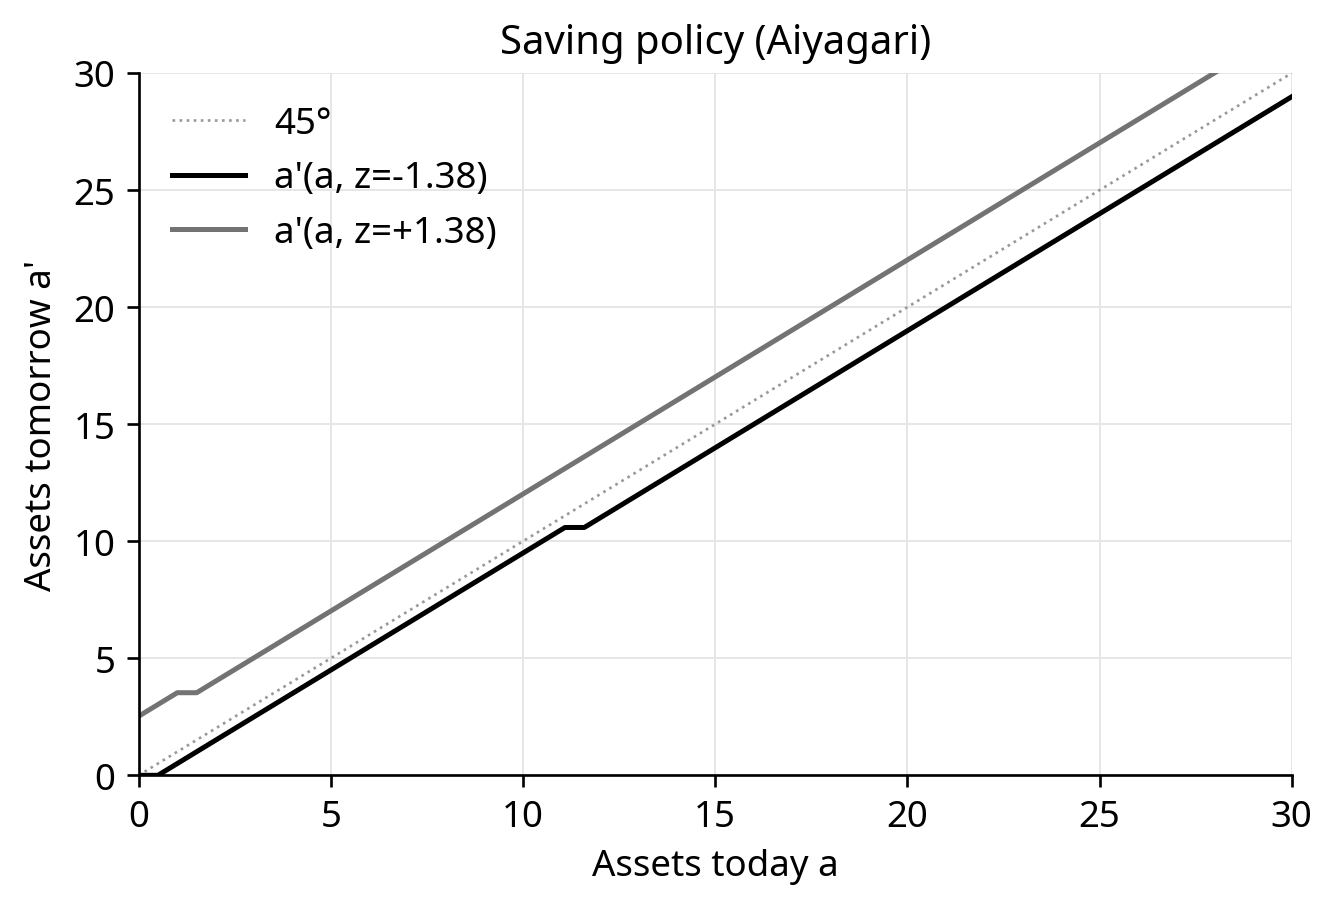

In [7]:
pol_a = a_grid[eq.solution.policy_aprime]                 # (n_a, n_z) realized a'
fig, ax = plt.subplots()
ax.plot(a_grid, a_grid, color="0.6", linewidth=0.8, linestyle=":", label="45°")
for j, c in zip([0, len(z_grid) - 1], _nbstyle.palette(2)):
    ax.plot(a_grid, pol_a[:, j], color=c, label=f"a'(a, z={z_grid[j]:+.2f})")
ax.set_xlim(0, 30); ax.set_ylim(0, 30)
ax.set_xlabel("Assets today a"); ax.set_ylabel("Assets tomorrow a'")
ax.set_title("Saving policy (Aiyagari)"); ax.legend(loc="upper left")
plt.show()

## Your turn — how much does patience heterogeneity matter?

The mixture above used `betas = [0.96, 0.93]`. Widen or narrow the spread — *keeping prices
fixed*, so this is cheap (no GE re-solve) — and watch the Gini respond. Change `betas_you`.

Tip: widening the *impatient* side is the reliable lever. Push the *patient* β to 0.97+ and
the Gini can actually *fall* — at the fixed rate those households drift up and pile at the
top of the asset grid `a_max`, which compresses the top of the distribution.

In [8]:
# ← Change this β spread (patient first, impatient second). Keep both < 1.
betas_you, weights_you = [0.96, 0.92], [0.5, 0.5]

def build_type_you(t):
    b = betas_you[t]
    def rf(ap, a, z, xp=np):
        c = w_star * xp.exp(z) + (1.0 + r_star) * a - ap
        return xp.where(c > 0.0, xp.log(xp.maximum(c, 1e-12)), -np.inf)
    return VFIProblem(a_grid=a_grid, z_grid=z_grid, P_z=P_z, return_fn=rf,
                      beta=b, options=dict(tol=1e-9, n_howard=40))

pt_you = solve_permanent_types(build_type_you, weights_you)
mu_you = pt_you.mixture_distribution()
_, _, gini_you = lorenz_and_gini(mu_you, np.broadcast_to(a_grid[:, None], mu_you.shape))
print(f"β spread {betas_you}: mixture Gini = {gini_you:.3f}  "
      f"(baseline [0.96, 0.93] → {gini_mix:.3f}; homogeneous → {gini_ai:.3f})")
assert gini_you > gini_ai, f"{gini_you:.3f} ≤ {gini_ai:.3f}: a near-unit-root patient β piles mass at a_max and compresses the top — see the Tip above"

β spread [0.96, 0.92]: mixture Gini = 0.801  (baseline [0.96, 0.93] → 0.794; homogeneous → 0.632)


**Prompts.** (1) Shrink the spread to `[0.955, 0.945]` — does the Gini fall toward the
homogeneous value? (2) Make the weights asymmetric (`[0.8, 0.2]`). (3) *Stretch* (slow,
re-solves GE): call `aiyagari_steady_state(..., sigma=0.30)` to raise income risk and
compare `wealth_gini` to the baseline `sigma=0.2`.

**How comprehensive is this?** `puremacro.vfi` is a full heterogeneous-agent toolkit. The
same `VFIProblem` → solve → stationary-distribution → market-clearing stack powers the
other showcase notebooks: **Krusell-Smith** aggregate risk and transition paths (NB02),
**life-cycle / OLG** with mortality (NB03), **Hopenhayn** firm entry/exit (NB04), and
**two-asset** portfolios with EGM and Epstein-Zin preferences (NB05). Endogenous grids,
permanent types, and GE transitions are all first-class.